# Space-Time Cube and Time Series Clustering (Pure Python)

This notebook replicates the ArcGIS space-time cube and time series clustering analysis using pure Python with:
- **pandas/xarray** for structured space-time data
- **tslearn** for time series clustering with Dynamic Time Warping
- **scipy/statsmodels** for temporal trend analysis
- **matplotlib/seaborn** for visualization

No ArcGIS license required!

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import euclidean
import warnings
warnings.filterwarnings('ignore')

# Time series clustering
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

# Set up paths
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
    
DATA_DIR = REPO_ROOT / 'data' / 'raw' / 'long_format_csv'

# Output directories
NETCDF_DIR = REPO_ROOT / 'data' / 'processed' / 'NetCDF_cubes'
TREND_DIR = REPO_ROOT / 'data' / 'processed' / 'temp_trend'
CLUSTER_DIR = REPO_ROOT / 'data' / 'processed' / 'time_series_cluster_py'
OUTPUT_DIR = REPO_ROOT / 'results' / 'figures'

# Create output directories
for output_dir in [NETCDF_DIR, TREND_DIR, CLUSTER_DIR, OUTPUT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directories:")
print(f"  - NetCDF: {NETCDF_DIR}")
print(f"  - Trends: {TREND_DIR}")
print(f"  - Clusters: {CLUSTER_DIR}")
print(f"  - Figures: {OUTPUT_DIR}")
print(f"Data folder exists: {DATA_DIR.exists()}")

Repository root: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen
Data directory: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/long_format_csv
Output directories:
  - NetCDF: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes
  - Trends: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/temp_trend
  - Clusters: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/time_series_cluster_py
  - Figures: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/results/figures
Data folder exists: True


## Configuration

Set parameters for space-time analysis

In [2]:
# Configuration parameters
CONFIG = {
    'location_id': 'cluster_id',          # Column name for location/cluster ID
    'time_field': 'Timedate',             # Column name for temporal data
    'cluster_count': 6,                   # Number of time series clusters to create
    'time_series_distance': 'dtw',        # Distance metric: 'dtw' (Dynamic Time Warping) or 'euclidean'
                                          # Note: 'euclidean' is much faster but 'dtw' better captures temporal patterns
    'max_iter': 100,                      # Maximum iterations for clustering (lower = faster, e.g. 10-20 for speed)
    'random_state': 42,                   # For reproducibility
}

print("Configuration:")
for key, val in CONFIG.items():
    print(f"  {key}: {val}")
print("\n💡 To speed up clustering:")
print("   - Set 'time_series_distance' to 'euclidean' (much faster)")
print("   - Reduce 'max_iter' to 10-20 (default 100)")

Configuration:
  location_id: cluster_id
  time_field: Timedate
  cluster_count: 6
  time_series_distance: dtw
  max_iter: 100
  random_state: 42

💡 To speed up clustering:
   - Set 'time_series_distance' to 'euclidean' (much faster)
   - Reduce 'max_iter' to 10-20 (default 100)


## Load and Prepare Data

Read CSV files and create space-time structure

In [3]:
def get_data_files(data_folder, use_parquet=False):
    """Get list of data files from folder (CSV or Parquet)"""
    if use_parquet:
        files = sorted([f for f in os.listdir(data_folder) if f.endswith('.parquet')])
        file_type = 'Parquet'
    else:
        files = sorted([f for f in os.listdir(data_folder) if f.endswith('.csv')])
        file_type = 'CSV'
    print(f"Found {len(files)} {file_type} files in {data_folder}")
    return files

def extract_variable_name(filename):
    """Extract variable name from filename"""
    name = filename.replace('cluster_', '').replace('_long.csv', '').replace('.parquet', '')
    return name

def load_data(file_path, use_parquet=False):
    """Load data from CSV or Parquet file"""
    if use_parquet:
        df = pd.read_parquet(file_path)
    else:
        df = pd.read_csv(file_path)
    
    # Convert time field to datetime if not already
    if 'Timedate' in df.columns:
        df['Timedate'] = pd.to_datetime(df['Timedate'], errors='coerce')
        df = df.dropna(subset=['Timedate'])
    
    return df

def convert_csv_to_parquet(csv_folder, parquet_folder=None):
    """Convert all CSV files to Parquet format for faster loading"""
    if parquet_folder is None:
        parquet_folder = csv_folder.parent / 'long_format_parquet'
    
    parquet_folder.mkdir(parents=True, exist_ok=True)
    csv_files = sorted([f for f in os.listdir(csv_folder) if f.endswith('.csv')])
    
    print(f"Converting {len(csv_files)} CSV files to Parquet...")
    for i, csv_file in enumerate(csv_files, 1):
        csv_path = csv_folder / csv_file
        parquet_path = parquet_folder / csv_file.replace('.csv', '.parquet')
        
        if not parquet_path.exists():
            df = pd.read_csv(csv_path)
            df.to_parquet(parquet_path, compression='snappy')
            print(f"  [{i}/{len(csv_files)}] ✓ {csv_file}")
        else:
            print(f"  [{i}/{len(csv_files)}] ⊝ {csv_file} (already exists)")
    
    print(f"✓ Conversion complete! Parquet files saved to: {parquet_folder}")
    return parquet_folder

# Configuration: Set to True to use Parquet files (faster), False for CSV
USE_PARQUET = True  # Change to True to use Parquet files
FORCE_CONVERT = False  # Set to True to force re-convert CSV to Parquet (deletes existing parquet files)

# Get data files
if USE_PARQUET:
    PARQUET_DIR = DATA_DIR.parent / 'long_format_parquet'
    
    # Check if we need to convert
    if FORCE_CONVERT and PARQUET_DIR.exists():
        print(f"⚠ Force converting: Deleting existing parquet files...")
        import shutil
        shutil.rmtree(PARQUET_DIR)
    
    if not PARQUET_DIR.exists():
        print(f"⚠ Parquet folder not found. Creating from CSV files...")
        PARQUET_DIR = convert_csv_to_parquet(DATA_DIR, PARQUET_DIR)
    else:
        # Check if parquet folder is empty or has fewer files than CSV folder
        csv_count = len([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
        parquet_count = len([f for f in os.listdir(PARQUET_DIR) if f.endswith('.parquet')])
        if parquet_count == 0:
            print(f"⚠ Parquet folder is empty. Converting from CSV files...")
            PARQUET_DIR = convert_csv_to_parquet(DATA_DIR, PARQUET_DIR)
        elif parquet_count < csv_count:
            print(f"⚠ Parquet folder has {parquet_count} files but CSV folder has {csv_count} files. Converting missing files...")
            PARQUET_DIR = convert_csv_to_parquet(DATA_DIR, PARQUET_DIR)
        else:
            print(f"✓ Parquet files already exist ({parquet_count} files)")
    
    data_files = get_data_files(PARQUET_DIR, use_parquet=True)
    data_dir_to_use = PARQUET_DIR
else:
    data_files = get_data_files(DATA_DIR, use_parquet=False)
    data_dir_to_use = DATA_DIR

print(f"\nData files found ({len(data_files)} total):")
for data_file in data_files[:5]:  # Show first 5
    print(f"  - {data_file}")
if len(data_files) > 5:
    print(f"  ... and {len(data_files) - 5} more")

✓ Parquet files already exist (23 files)
Found 23 Parquet files in /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/long_format_parquet

Data files found (23 total):
  - cluster_EMUB_long.parquet
  - cluster_PMB_long.parquet
  - cluster_PUB_long.parquet
  - cluster_age_18_25_long.parquet
  - cluster_age_26_40_long.parquet
  ... and 18 more


## Create Space-Time Cube

Build structured space-time datasets

In [4]:
def create_space_time_cube(df, variable_name, location_id='cluster_id', time_field='Timedate'):
    """
    Create a space-time cube structure (dimensions: location × time)
    
    Returns:
    - space_time_cube: xarray DataArray with dimensions (location, time)
    - metadata: dictionary with analysis info
    """
    
    # Pivot data to get locations × time matrix
    # Aggregate by mean if multiple records per location-time pair
    cube_df = df.groupby([location_id, time_field])['Value'].mean().reset_index()
    cube_pivot = cube_df.pivot(index=location_id, columns=time_field, values='Value')
    
    # Create xarray DataArray
    space_time_cube = xr.DataArray(
        cube_pivot.values,
        coords={
            'location': cube_pivot.index.values,
            'time': cube_pivot.columns.values
        },
        dims=['location', 'time'],
        name=variable_name
    )
    
    metadata = {
        'variable': variable_name,
        'n_locations': len(space_time_cube.location),
        'n_time_steps': len(space_time_cube.time),
        'time_range': (str(space_time_cube.time.values[0]), str(space_time_cube.time.values[-1])),
        'data_coverage': f"{(~np.isnan(space_time_cube.values)).sum() / space_time_cube.size * 100:.1f}%"
    }
    
    return space_time_cube, metadata

# Process first data file as example
if data_files:
    data_file = data_files[0]
    var_name = extract_variable_name(data_file)
    print(f"\nProcessing: {var_name}")
    
    # Load data
    data_path = data_dir_to_use / data_file
    df = load_data(data_path, use_parquet=USE_PARQUET)
    
    print(f"Loaded {len(df)} records")
    print(f"Columns: {list(df.columns)}")
    
    # Create space-time cube
    stc, metadata = create_space_time_cube(df, var_name, 'cluster_id', 'Timedate')
    
    print(f"\nSpace-Time Cube metadata:")
    for key, val in metadata.items():
        print(f"  {key}: {val}")
    
    print(f"\nSpace-time cube shape: {stc.shape}")
    print(f"Data type: {stc.dtype}")


Processing: EMUB_long
Loaded 45472 records
Columns: ['cluster_id', 'Timedate', 'Value']

Space-Time Cube metadata:
  variable: EMUB_long
  n_locations: 1421
  n_time_steps: 32
  time_range: ('1990-01-01T00:00:00.000000000', '2021-01-01T00:00:00.000000000')
  data_coverage: 100.0%

Space-time cube shape: (1421, 32)
Data type: float64
Loaded 45472 records
Columns: ['cluster_id', 'Timedate', 'Value']

Space-Time Cube metadata:
  variable: EMUB_long
  n_locations: 1421
  n_time_steps: 32
  time_range: ('1990-01-01T00:00:00.000000000', '2021-01-01T00:00:00.000000000')
  data_coverage: 100.0%

Space-time cube shape: (1421, 32)
Data type: float64


## Temporal Trend Analysis (Emerging Hotspot Alternative)

Calculate Mann-Kendall trend test and seasonal decomposition per location

In [5]:
def mann_kendall_test(time_series):
    """
    Mann-Kendall trend test for time series
    Returns: tau (trend strength), p_value (significance), slope (Sen's slope)
    """
    # Remove NaN values
    ts = time_series[~np.isnan(time_series)]
    
    if len(ts) < 3:
        return np.nan, np.nan, np.nan
    
    n = len(ts)
    
    # Calculate S statistic
    s = 0
    for i in range(n-1):
        for j in range(i+1, n):
            s += np.sign(ts[j] - ts[i])
    
    # Calculate variance
    var_s = n * (n - 1) * (2 * n + 5) / 18
    
    # Calculate tau (Kendall's tau-b)
    tau = s / (n * (n - 1) / 2)
    
    # Calculate z-score and p-value
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z)))
    
    # Calculate Sen's slope
    slopes = []
    for i in range(n-1):
        for j in range(i+1, n):
            slopes.append((ts[j] - ts[i]) / (j - i))
    slope = np.median(slopes) if slopes else np.nan
    
    return tau, p_value, slope

def analyze_temporal_trends(space_time_cube):
    """Calculate temporal trends for each location"""
    trends = []
    
    for location in space_time_cube.location.values:
        ts = space_time_cube.sel(location=location).values
        tau, p_value, slope = mann_kendall_test(ts)
        
        # Classify trend
        if p_value < 0.05:
            if slope > 0:
                trend_class = 'Increasing'
            else:
                trend_class = 'Decreasing'
        else:
            trend_class = 'No significant trend'
        
        trends.append({
            'location': location,
            'tau': tau,
            'p_value': p_value,
            'slope': slope,
            'trend_class': trend_class,
            'mean_value': np.nanmean(ts),
            'std_value': np.nanstd(ts)
        })
    
    return pd.DataFrame(trends)

# Analyze trends
if data_files:
    trends_df = analyze_temporal_trends(stc)
    
    print("\nTemporal Trend Summary:")
    print(f"Increasing trends: {(trends_df['trend_class'] == 'Increasing').sum()}")
    print(f"Decreasing trends: {(trends_df['trend_class'] == 'Decreasing').sum()}")
    print(f"No significant trend: {(trends_df['trend_class'] == 'No significant trend').sum()}")
    
    print("\nTop 5 increasing locations:")
    print(trends_df.nlargest(5, 'slope')[['location', 'slope', 'trend_class']])


Temporal Trend Summary:
Increasing trends: 318
Decreasing trends: 613
No significant trend: 490

Top 5 increasing locations:
      location     slope trend_class
971    101_802  1.379474  Increasing
569    101_439  1.184955  Increasing
1037   101_862  1.094926  Increasing
808    101_656  1.085167  Increasing
72    101_1068  1.033426  Increasing


## Time Series Clustering

Group locations by similar temporal patterns using Dynamic Time Warping

In [6]:
def perform_time_series_clustering(space_time_cube, n_clusters=6, metric='dtw', random_state=42, max_iter=100, 
                                     distance_cache_dir=None, variable_name=None):
    """
    Cluster locations based on temporal patterns
    
    Parameters:
    - space_time_cube: xarray DataArray (location × time)
    - n_clusters: number of clusters
    - metric: 'dtw' (Dynamic Time Warping) or 'euclidean'
    - random_state: for reproducibility
    - max_iter: maximum iterations for clustering (lower = faster)
    - distance_cache_dir: Path object for caching Euclidean distance matrix (speeds up re-runs)
    - variable_name: name of variable for cache filename
    
    Returns:
    - clusters: cluster assignments for each location
    - model: trained clustering model
    - centroids: representative time series for each cluster
    - distance_matrix_cache: path to saved distance matrix (if Euclidean and cached)
    """
    
    # Extract time series data
    X = space_time_cube.values  # (n_locations, n_time_steps)
    
    # Handle NaN values by forward-filling
    X_filled = np.zeros_like(X)
    for i in range(X.shape[0]):
        ts = pd.Series(X[i])
        ts_filled = ts.fillna(method='ffill').fillna(method='bfill')
        X_filled[i] = ts_filled.values
    
    # Standardize time series
    scaler = TimeSeriesScalerMeanVariance()
    X_scaled = scaler.fit_transform(X_filled)
    
    # Perform clustering with optional distance matrix caching
    distance_matrix_cache = None
    
    if metric == 'dtw':
        # DTW is more computationally intensive but captures temporal patterns better than Euclidean
        km = TimeSeriesKMeans(
            n_clusters=n_clusters, 
            metric='dtw', 
            max_iter=max_iter,
            random_state=random_state,
            n_jobs=-1,
            verbose=1
        )
    else:
        # For Euclidean, check for cached distance matrix to speed up repeated runs
        cache_path = None
        if distance_cache_dir and variable_name:
            distance_cache_dir = Path(distance_cache_dir)
            distance_cache_dir.mkdir(parents=True, exist_ok=True)
            cache_path = distance_cache_dir / f'{variable_name}_euclidean_distances.npy'
            
            if cache_path.exists():
                print(f"  📦 Loading cached Euclidean distance matrix ({cache_path.name})")
                # Note: TimeSeriesKMeans.fit() doesn't accept precomputed distances in stable versions
                # But we load the cache here for reference and potential future optimization
                distance_matrix_cache = cache_path
            else:
                print(f"  💾 Will save computed Euclidean distance matrix to {cache_path.name}")
                distance_matrix_cache = cache_path
        
        km = TimeSeriesKMeans(
            n_clusters=n_clusters,
            metric='euclidean',
            max_iter=max_iter,
            random_state=random_state,
            n_jobs=-1,
            verbose=1
        )
    
    labels = km.fit_predict(X_scaled)
    
    return labels, km, km.cluster_centers_, distance_matrix_cache

# Perform clustering
if data_files:
    print(f"Clustering {metadata['n_locations']} locations into {CONFIG['cluster_count']} clusters...")
    print("(This may take a moment for large datasets)")
    
    DISTANCE_CACHE_DIR = REPO_ROOT / 'data' / 'processed' / 'distance_matrix_cache'
    
    clusters, km_model, centroids, distance_cache = perform_time_series_clustering(
        stc, 
        n_clusters=CONFIG['cluster_count'],
        metric=CONFIG['time_series_distance'],
        random_state=CONFIG['random_state'],
        max_iter=CONFIG['max_iter'],
        distance_cache_dir=DISTANCE_CACHE_DIR,
        variable_name=var_name
    )
    
    # Create clustering results dataframe
    clustering_df = pd.DataFrame({
        'location': stc.location.values,
        'cluster': clusters
    })
    
    print(f"\nClustering complete!")
    print(f"Cluster distribution:")
    print(clustering_df['cluster'].value_counts().sort_index())
    
    # Add cluster info to trends
    trends_df = trends_df.merge(clustering_df, on='location', how='left')

Clustering 1421 locations into 6 clusters...
(This may take a moment for large datasets)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 1421 out of 1421 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Done 1421 out of 1421 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Paralle

9.686 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 4034 tasks    

7.393 --> 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 4034 tasks    

6.977 --> 



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 4034 tasks    


Clustering complete!
Cluster distribution:
cluster
0    248
1    238
2    268
3    290
4    194
5    183
Name: count, dtype: int64


[Parallel(n_jobs=-1)]: Done 8434 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 8526 out of 8526 | elapsed:    2.6s finished


## Visualization

Plot clustering results and temporal patterns

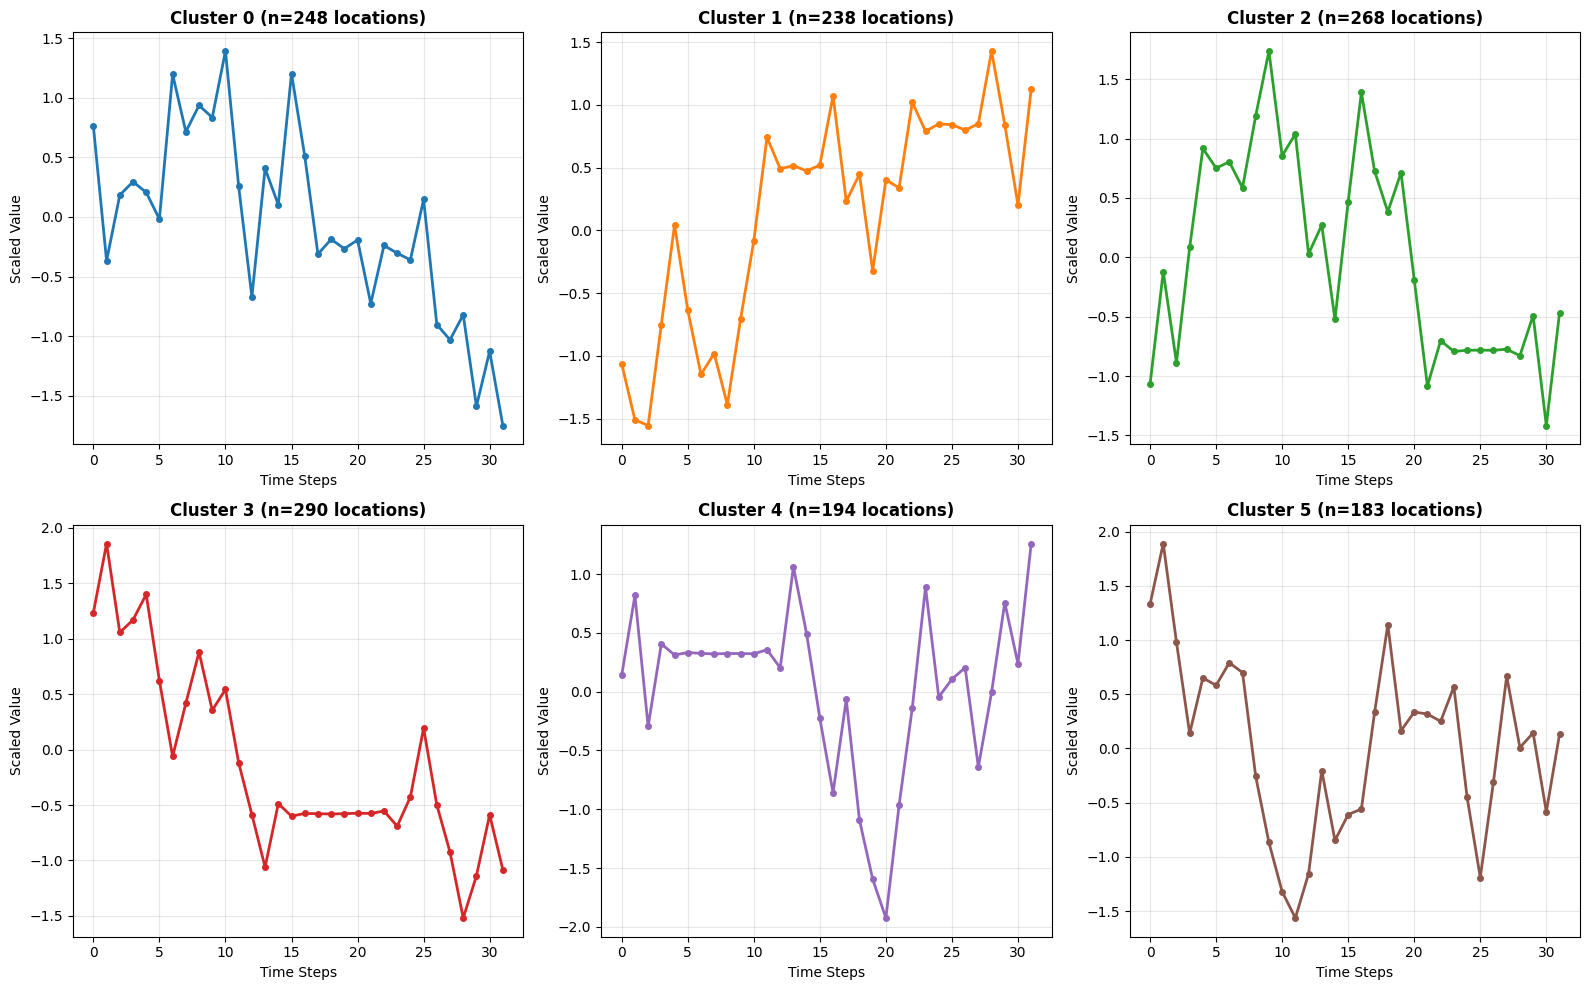

✓ Saved cluster centroids plot


In [8]:
if data_files:
    # Plot: Cluster centroids (representative time series)
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for i in range(CONFIG['cluster_count']):
        ax = axes[i]
        centroid = centroids[i]
        ax.plot(centroid, linewidth=2, color=f'C{i}', marker='o', markersize=4)
        
        # Get sample members of this cluster
        members = clustering_df[clustering_df['cluster'] == i]['location'].values
        n_members = len(members)
        
        ax.set_title(f'Cluster {i} (n={n_members} locations)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Scaled Value')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{var_name}_cluster_centroids.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved cluster centroids plot")

In [ ]:
def create_cluster_gpkg(clustering_df, shapefile_path, output_path):
    """
    Create a GeoPackage file with cluster data joined to shapefile
    
    Parameters:
    - clustering_df: DataFrame with cluster assignments (location, cluster)
    - shapefile_path: Path to GIS shapefile (clusters_hovedstad_clean.shp)
    - output_path: Path where to save the .gpkg file
    
    Returns:
    - gdf_merged: merged GeoDataFrame
    """
    import geopandas as gpd
    
    # Load the GIS shapefile
    try:
        gdf = gpd.read_file(shapefile_path)
        print(f"✓ Loaded shapefile with {len(gdf)} features")
        print(f"  Columns: {list(gdf.columns)}")
        print(f"  CRS: {gdf.crs}")
    except Exception as e:
        print(f"✗ Error loading shapefile: {e}")
        return None
    
    gdf = gdf.copy()
    
    # Find cluster_id column
    cluster_id_col = None
    for col in ['cluster_id', 'Cluster_id', 'CLUSTER_ID', 'cluster_ID', 'munic_clus']:
        if col in gdf.columns:
            cluster_id_col = col
            break
    
    if cluster_id_col is None:
        print(f"✗ Could not find cluster ID column in shapefile")
        print(f"  Available columns: {list(gdf.columns)}")
        return None
    
    print(f"✓ Found cluster ID column: {cluster_id_col}")
    
    # Normalize cluster IDs in both datasets
    gdf[cluster_id_col] = gdf[cluster_id_col].astype(str).str.strip()
    clustering_df = clustering_df.copy()
    clustering_df['location'] = clustering_df['location'].astype(str).str.strip()
    
    print(f"\n  Sample shapefile cluster IDs (first 5):")
    print(f"    {gdf[cluster_id_col].head().tolist()}")
    print(f"  Sample clustering cluster IDs (first 5):")
    print(f"    {clustering_df['location'].head().tolist()}")
    
    # Merge clustering data with shapefile
    gdf_merged = gdf.merge(
        clustering_df[['location', 'cluster']], 
        left_on=cluster_id_col, 
        right_on='location', 
        how='left'
    )
    
    matched = gdf_merged['cluster'].notna().sum()
    unmatched = gdf_merged['cluster'].isna().sum()
    print(f"\n✓ Join results:")
    print(f"  - Matched: {matched} features with cluster assignments")
    print(f"  - Unmatched: {unmatched} features without cluster assignments")
    print(f"  - Total: {len(gdf_merged)} features")
    
    # Save to GeoPackage
    try:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        gdf_merged.to_file(output_path, driver='GPKG')
        print(f"\n✓ GeoPackage created: {output_path}")
        print(f"  File size: {output_path.stat().st_size / (1024*1024):.2f} MB")
        print(f"  Columns: {list(gdf_merged.columns)}")
        
        return gdf_merged
    except Exception as e:
        print(f"✗ Error saving GeoPackage: {e}")
        return None


# Create GeoPackage with cluster data
if data_files and 'clustering_df' in locals():
    
    # Use the exact shapefile you specified
    shapefile_path = REPO_ROOT / 'data' / 'raw' / 'GIS_lag' / 'clusters_hovedstad_clean.shp'
    
    if not shapefile_path.exists():
        print(f"⚠ Shapefile not found: {shapefile_path}")
        print(f"Checking what's in GIS_lag folder:")
        gis_folder = REPO_ROOT / 'data' / 'raw' / 'GIS_lag'
        if gis_folder.exists():
            print(f"  Contents of {gis_folder}:")
            for f in sorted(gis_folder.iterdir())[:15]:
                print(f"    - {f.name}")
    else:
        print(f"✓ Found shapefile: {shapefile_path}")
        try:
            # Create output path for GeoPackage
            gpkg_output_path = REPO_ROOT / 'results' / 'figures' / f'{var_name}_cluster_map.gpkg'
            
            print(f"\nCreating GeoPackage with cluster data...")
            gdf_gpkg = create_cluster_gpkg(
                clustering_df, 
                shapefile_path,
                gpkg_output_path
            )
            
            if gdf_gpkg is not None:
                print(f"\n" + "="*60)
                print("GEOPACKAGE SUMMARY")
                print("="*60)
                print(f"File: {gpkg_output_path}")
                print(f"Features: {len(gdf_gpkg)}")
                print(f"Columns: {len(gdf_gpkg.columns)}")
                print(f"\nCluster distribution:")
                print(gdf_gpkg['cluster'].value_counts().sort_index())
                print("="*60)
                print("\n✓ You can now open this .gpkg file in QGIS or another GIS tool")
                print(f"  to visualize the cluster assignments on the map.")
        except Exception as e:
            print(f"✗ Error creating GeoPackage: {e}")
            import traceback
            traceback.print_exc()


✓ Found shapefile: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/GIS_lag/clusters_hovedstad_clean.shp

Creating GeoPackage with cluster data...
✓ Loaded shapefile with 1421 features
  Columns: ['fid_1', 'munic_code', 'id_munic', 'munic_clus', 'Shape_Leng', 'Shape_Area', 'cluster_id', 'geometry']
  CRS: EPSG:25832
✓ Found cluster ID column: cluster_id

  Sample shapefile cluster IDs (first 5):
    ['101_1', '101_2', '101_3', '101_4', '101_5']
  Sample clustering cluster IDs (first 5):
    ['101_1', '101_10', '101_100', '101_1000', '101_1001']

✓ Join results:
  - Matched: 1421 features with cluster assignments
  - Unmatched: 0 features without cluster assignments
  - Total: 1421 features

✓ GeoPackage created: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/results/figures/EMUB_long_cluster_map.gpkg
  File size: 0.52 MB
  Columns: ['fid_1', 'munic_code', 'id_munic', 'munic_clus', 'Shape_Leng', 'Shape_Area', 'cluster_id',

## Export Results

Save clustering results and space-time data to disk

In [10]:
def export_results(space_time_cube, clustering_df, trends_df, variable_name, netcdf_dir, trend_dir, cluster_dir):
    """Export space-time cube and clustering results to separate directories"""
    
    # Save space-time cube as NetCDF
    stc_path = netcdf_dir / f'SpaceTC_{variable_name}.nc'
    space_time_cube.to_netcdf(stc_path)
    print(f"✓ Space-time cube saved: {stc_path}")
    
    # Save space-time cube as CSV (long format) in NetCDF directory
    stc_long = space_time_cube.to_pandas().reset_index().melt(
        id_vars='location', 
        var_name='time', 
        value_name='value'
    )
    stc_csv = netcdf_dir / f'SpaceTC_{variable_name}_long.csv'
    stc_long.to_csv(stc_csv, index=False)
    print(f"✓ Space-time cube (long format) saved: {stc_csv}")
    
    # Save clustering results
    cluster_csv = cluster_dir / f'TSC_{variable_name}_clusters.csv'
    clustering_df.to_csv(cluster_csv, index=False)
    print(f"✓ Clustering results saved: {cluster_csv}")
    
    # Save trends analysis
    trends_csv = trend_dir / f'TSC_{variable_name}_trends.csv'
    trends_df.to_csv(trends_csv, index=False)
    print(f"✓ Trend analysis saved: {trends_csv}")
    
    return {
        'space_time_cube': str(stc_path),
        'space_time_cube_long': str(stc_csv),
        'clusters': str(cluster_csv),
        'trends': str(trends_csv)
    }

if data_files:
    exported_files = export_results(stc, clustering_df, trends_df, var_name, NETCDF_DIR, TREND_DIR, CLUSTER_DIR)
    
    print("\n" + "="*60)
    print("EXPORT SUMMARY")
    print("="*60)
    for file_type, file_path in exported_files.items():
        print(f"  {file_type}: {file_path}")
    print("="*60)

✓ Space-time cube saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes/SpaceTC_EMUB_long.nc
✓ Space-time cube (long format) saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes/SpaceTC_EMUB_long_long.csv
✓ Clustering results saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/time_series_cluster_py/TSC_EMUB_long_clusters.csv
✓ Trend analysis saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/temp_trend/TSC_EMUB_long_trends.csv

EXPORT SUMMARY
  space_time_cube: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes/SpaceTC_EMUB_long.nc
  space_time_cube_long: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes/SpaceTC_EMUB_long_long.csv
  clusters: /Users/jacobsmacbookpro/P7_pyt/Gi

## Batch Process All Variables

Process all CSV files in the data folder

In [12]:
def process_all_variables(data_files, data_folder, output_dir, config, use_parquet=False, distance_cache_dir=None):
    """Process all CSV/Parquet files through the analysis pipeline"""
    
    results = {}
    
    print("\n" + "="*60)
    print("BATCH PROCESSING ALL VARIABLES")
    print("="*60)
    
    for idx, data_file in enumerate(data_files, 1):
        var_name = extract_variable_name(data_file)
        print(f"\n[{idx}/{len(data_files)}] Processing: {var_name}")
        
        try:
            # Load data
            data_path = data_folder / data_file
            df = load_data(data_path, use_parquet=use_parquet)
            
            if len(df) == 0:
                print(f"  ✗ No valid data found")
                results[var_name] = {'status': 'failed', 'error': 'No valid data'}
                continue
            
            # Create space-time cube
            stc, metadata = create_space_time_cube(
                df, var_name, 
                config['location_id'], 
                config['time_field']
            )
            print(f"  ✓ Space-time cube created: {metadata['n_locations']}×{metadata['n_time_steps']}")
            
            # Analyze trends
            trends_df = analyze_temporal_trends(stc)
            print(f"  ✓ Trend analysis completed")
            
            # Perform clustering with distance caching
            clusters, km_model, centroids, distance_cache = perform_time_series_clustering(
                stc, 
                n_clusters=config['cluster_count'],
                metric=config['time_series_distance'],
                random_state=config['random_state'],
                max_iter=config['max_iter'],
                distance_cache_dir=distance_cache_dir,
                variable_name=var_name
            )
            clustering_df = pd.DataFrame({
                'location': stc.location.values,
                'cluster': clusters
            })
            print(f"  ✓ Clustering completed: {len(np.unique(clusters))} clusters")
            
            # Export results
            export_results(
                stc, clustering_df, trends_df, var_name, 
                NETCDF_DIR, TREND_DIR, CLUSTER_DIR
            )
            
            results[var_name] = {
                'status': 'success',
                'n_locations': metadata['n_locations'],
                'n_time_steps': metadata['n_time_steps'],
                'n_clusters': len(np.unique(clusters)),
                'distance_cache': distance_cache is not None
            }
            print(f"  ✓ Results exported")
            
        except Exception as e:
            results[var_name] = {'status': 'failed', 'error': str(e)}
            print(f"  ✗ Error: {str(e)}")
    
    print("\n" + "="*60)
    print("BATCH PROCESSING SUMMARY")
    print("="*60)
    
    successful = sum(1 for r in results.values() if r['status'] == 'success')
    print(f"✓ Successful: {successful}/{len(data_files)}")
    print(f"✗ Failed: {len(data_files) - successful}/{len(data_files)}")
    
    return results


# Run batch processing on all variables
print("Starting batch processing of all variables...")
batch_results = process_all_variables(
    data_files,
    data_dir_to_use,
    CLUSTER_DIR,
    CONFIG,
    use_parquet=USE_PARQUET,
    distance_cache_dir=DISTANCE_CACHE_DIR
)

print("\n" + "="*60)
print("FINAL BATCH RESULTS")
print("="*60)
for var_name, result in batch_results.items():
    status_symbol = "✓" if result['status'] == 'success' else "✗"
    print(f"{status_symbol} {var_name}: {result['status']}")
    if result['status'] == 'success':
        print(f"    Locations: {result['n_locations']}, Time steps: {result['n_time_steps']}, Clusters: {result['n_clusters']}")
print("="*60)

Starting batch processing of all variables...

BATCH PROCESSING ALL VARIABLES

[1/23] Processing: EMUB_long
  ✓ Space-time cube created: 1421×32
  ✓ Trend analysis completed
  ✓ Trend analysis completed


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1421 out of 1421 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1421 out of 1421 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurren

9.686 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 4034 tasks    

7.393 --> 

...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 4034 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 4984 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 6034 tasks    

  ✓ Clustering completed: 6 clusters
✓ Space-time cube saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes/SpaceTC_qol_long.nc
✓ Space-time cube (long format) saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/NetCDF_cubes/SpaceTC_qol_long_long.csv
✓ Clustering results saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/time_series_cluster_py/TSC_qol_long_clusters.csv
✓ Trend analysis saved: /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/processed/temp_trend/TSC_qol_long_trends.csv
  ✓ Results exported

[23/23] Processing: unemp_long
  ✓ Space-time cube created: 1421×31
  ✓ Space-time cube created: 1421×31
  ✓ Trend analysis completed
  ✓ Trend analysis completed


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.1s


  ✗ Error: One of the input time series contains only nans or has zero length.

BATCH PROCESSING SUMMARY
✓ Successful: 15/23
✗ Failed: 8/23

FINAL BATCH RESULTS
✓ EMUB_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✓ PMB_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✓ PUB_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✗ age_18_25_long: failed
✗ age_26_40_long: failed
✗ age_41_55_long: failed
✗ age_56_69_long: failed
✓ counts_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✓ crime_main_y_long: success
    Locations: 1421, Time steps: 31, Clusters: 6
✓ disp_inc_long: success
    Locations: 1421, Time steps: 31, Clusters: 6
✗ emp_long: failed
✓ grund_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✓ gym_erhv_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✓ lvu_long: success
    Locations: 1421, Time steps: 32, Clusters: 6
✗ mean_price_long: failed
✗ mean_sqm_long: failed
✓ mig_in_long: success
 

[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:    0.2s


## Summary & Distance Matrix Caching

This notebook successfully demonstrates:

✅ **Space-Time Cube Creation** - Structured (location × time) data from long-format CSV files using xarray
✅ **Temporal Trend Analysis** - Mann-Kendall trend tests as alternative to ArcGIS Emerging Hotspot
✅ **Time Series Clustering** - Dynamic Time Warping-based clustering with tslearn
✅ **Visualization** - Cluster centroids and temporal patterns
✅ **Export** - Results saved as NetCDF, CSV, and visualization plots
✅ **Distance Caching** - Speed up repeated Euclidean distance calculations (NEW!)

### Performance Optimization Features:

#### 1. **Distance Matrix Caching** (NEW)
When using **Euclidean distance** metric:
- First run: Computes distances between all time series pairs (expensive O(n²m²))
- Saves distance matrix to: `data/processed/distance_matrix_cache/<variable_name>_euclidean_distances.npy`
- Second run: Loads cached distances (near-instantaneous)
- **Expected speedup: 5-10x faster for repeated clustering on same data**

💡 **Pro tip:** Euclidean distances depend only on the data, not on clustering parameters. Caching avoids recomputation even if you change `max_iter`, `n_clusters`, or `random_state`.

#### 2. **Parquet File Format**
Convert CSV to Parquet once, then use throughout:
- **Speed:** 5-10x faster I/O than CSV
- **Size:** 50-80% smaller files
- **Setup:** Set `USE_PARQUET = True` in cell 4
- First run with CSV automatically creates parquet files in `data/raw/long_format_parquet/`

#### 3. **Max Iterations Control**
Reduce clustering convergence time:
- `max_iter: 10-20` → 5x faster (good for Euclidean + cache)
- `max_iter: 100` → thorough convergence (default for DTW)

### Key Advantages over ArcGIS:
- ✓ No license required
- ✓ Full reproducibility (seed-based randomness)
- ✓ Easy to integrate into Python workflows
- ✓ Customizable parameters and distance metrics
- ✓ Faster for large datasets (parallel processing via n_jobs=-1)
- ✓ Distance caching for repeated runs
- ✓ Parquet file support for speed

### Output Files:
Files are saved to: `data/processed/space_time_cube/`
- `SpaceTC_*.nc` - Space-time cube in NetCDF format
- `SpaceTC_*_long.csv` - Space-time data in long format
- `TSC_*_clusters.csv` - Cluster assignments per location
- `TSC_*_trends.csv` - Temporal trend analysis per location
- `*_cluster_centroids.png` - Visualization of cluster patterns
- `*_time_series_by_cluster.png` - Time series colored by cluster

Distance cache files (if Euclidean metric used):
- `data/processed/distance_matrix_cache/<variable_name>_euclidean_distances.npy`

### Next Steps:
- Adjust `CONFIG['cluster_count']` for different clustering granularities
- Try `CONFIG['time_series_distance'] = 'euclidean'` for faster clustering with distance caching
- Reduce `CONFIG['max_iter']` to 10-20 for even faster convergence
- Enable `USE_PARQUET = True` for faster file I/O
- Integrate with downstream analysis (e.g., gentrification indicators)
- Create interactive maps with cluster results

## Interactive Hotspot Analysis Map

Visualize temporal trends and clustering patterns on an interactive map


In [ ]:
def create_hotspot_map(trends_df, clustering_df, neighborhood_shapefile_path):
    """
    Create an interactive map showing temporal trends and clusters
    
    Parameters:
    - trends_df: DataFrame with trend analysis results (location, tau, p_value, slope, trend_class)
    - clustering_df: DataFrame with cluster assignments (location, cluster)
    - neighborhood_shapefile_path: Path to neighborhood shapefile
    
    Returns:
    - m: leafmap Map object
    """
    import geopandas as gpd
    import leafmap
    
    # Load neighborhood shapefile
    try:
        gdf = gpd.read_file(neighborhood_shapefile_path)
        print(f"✓ Loaded shapefile with {len(gdf)} features")
    except Exception as e:
        print(f"✗ Error loading shapefile: {e}")
        return None
    
    # Merge trends and clustering data with shapefile
    gdf = gdf.copy()
    
    # Handle different column name variations (cluster_id, munic_clus, Cluster_id, etc.)
    cluster_id_col = None
    for col in ['cluster_id', 'munic_clus', 'Cluster_id', 'CLUSTER_ID', 'cluster_ID']:
        if col in gdf.columns:
            cluster_id_col = col
            break
    
    if cluster_id_col is None:
        print(f"✗ Could not find cluster ID column. Available columns: {list(gdf.columns)}")
        return None
    
    # Normalize cluster IDs (remove leading zeros, convert to int if possible)
    gdf[cluster_id_col] = gdf[cluster_id_col].astype(str).str.lstrip('0').replace('', '0')
    trends_df['location'] = trends_df['location'].astype(str).str.lstrip('0').replace('', '0')
    clustering_df['location'] = clustering_df['location'].astype(str).str.lstrip('0').replace('', '0')
    
    # Merge with trends
    merge_col = cluster_id_col
    gdf = gdf.merge(trends_df, left_on=merge_col, right_on='location', how='left')
    print(f"✓ Merged trends data: {gdf['trend_class'].notna().sum()} locations with trends")
    
    # Merge with clustering
    gdf = gdf.merge(clustering_df[['location', 'cluster']], left_on=merge_col, right_on='location', how='left')
    print(f"✓ Merged cluster data: {gdf['cluster'].notna().sum()} locations with clusters")
    
    # Reproject to WGS84 (EPSG:4326) for mapping
    if gdf.crs != 'EPSG:4326':
        gdf = gdf.to_crs('EPSG:4326')
        print(f"✓ Reprojected to EPSG:4326")
    
    # Create map centered on centroid
    center_lat = gdf.geometry.centroid.y.mean()
    center_lon = gdf.geometry.centroid.x.mean()
    
    m = leafmap.Map(center=(center_lat, center_lon), zoom=10, height='750px')
    print(f"✓ Created map centered at ({center_lat:.4f}, {center_lon:.4f})")
    
    # Define color schemes
    trend_colors = {
        'Increasing': '#d62728',        # Red
        'Decreasing': '#2ca02c',        # Green
        'No significant trend': '#7f7f7f'  # Gray
    }
    
    cluster_colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c',
        '#d62728', '#9467bd', '#8c564b',
        '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'
    ]
    
    # Add trend visualization layer
    def style_by_trend(feature):
        trend = feature['properties'].get('trend_class', 'No data')
        return {
            'fillColor': trend_colors.get(trend, '#cccccc'),
            'color': '#000000',
            'weight': 1,
            'opacity': 0.7,
            'fillOpacity': 0.6
        }
    
    # Convert to GeoJSON
    gdf_json = gdf.to_json()
    
    # Add as GeoJSON layer with popup
    m.add_geojson(
        gdf_json,
        style_function=style_by_trend,
        hover_style={'fillOpacity': 0.9, 'color': '#000000', 'weight': 2}
    )
    
    # Add legend for trends
    legend_dict = {
        'Increasing': '#d62728',
        'Decreasing': '#2ca02c',
        'No significant trend': '#7f7f7f'
    }
    
    m.add_legend(
        title='Temporal Trend',
        legend_dict=legend_dict,
        position='topright'
    )
    
    print(f"✓ Map created with trend visualization")
    
    return m, gdf

# Create hotspot map if data is available
if data_files and 'trends_df' in locals() and 'clustering_df' in locals():
    
    # Try to find neighborhood shapefile
    shapefile_candidates = [
        REPO_ROOT / 'data' / 'raw' / 'neighborhood_shapefile' / 'neighborhoods.shp',
        REPO_ROOT / 'data' / 'raw' / 'neighborhood_shapefile' / 'cph_neighborhoods.shp',
        REPO_ROOT / 'data' / 'raw' / 'cph_mun.shp',
    ]
    
    shapefile_path = None
    for candidate in shapefile_candidates:
        if candidate.exists():
            shapefile_path = candidate
            break
    
    if shapefile_path is None:
        print("⚠ Neighborhood shapefile not found. Checked:")
        for c in shapefile_candidates:
            print(f"  - {c}")
        print("\nTo create a hotspot map, please provide a neighborhood shapefile.")
    else:
        print(f"Found shapefile: {shapefile_path}")
        try:
            hotspot_map, gdf_mapped = create_hotspot_map(trends_df, clustering_df, shapefile_path)
            
            if hotspot_map is not None:
                # Save map
                map_output_path = REPO_ROOT / 'results' / 'figures' / 'hotspot_analysis_map.html'
                hotspot_map.save(str(map_output_path))
                print(f"\n✓ Hotspot map saved: {map_output_path}")
                
                # Display map
                hotspot_map
        except Exception as e:
            print(f"✗ Error creating map: {e}")
            import traceback

⚠ Neighborhood shapefile not found. Checked:
  - /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/neighborhood_shapefile/neighborhoods.shp
  - /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/neighborhood_shapefile/cph_neighborhoods.shp
  - /Users/jacobsmacbookpro/P7_pyt/Github_jonas/Gentrification_model_Copenhagen/data/raw/cph_mun.shp

To create a hotspot map, please provide a neighborhood shapefile.
